# Customer Segmentation using K-Means Clustering

## Prodigy InfoTech Machine Learning Internship

### Task-02

### Objective

The objective of this project is to segment mall customers into different groups based on their Annual Income and Spending Score using the K-Means Clustering algorithm.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

## Step 1: Load the Dataset

In this step, we load the Mall Customer Segmentation dataset using the Pandas library.

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 2: Explore the Dataset

Let's understand the dataset by checking its information, statistics, and missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Step 3: Feature Selection

We will use only two features for customer segmentation:

- Annual Income (k$)
- Spending Score (1-100)

In [6]:
X = df.iloc[:, [3,4]].values

X[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

## Step 4: Finding the Optimal Number of Clusters

The Elbow Method helps us determine the best value of K.

In [7]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

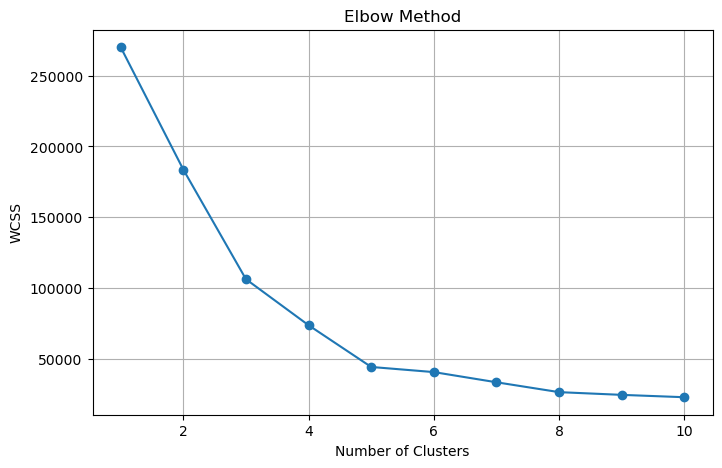

In [8]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

## Step 5: Train the K-Means Model

Based on the Elbow Method, we choose **K = 5** clusters.

In [9]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

y_kmeans

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

## Step 6: Visualize Customer Segments

Each color represents a different customer group, and the yellow stars represent the cluster centroids.

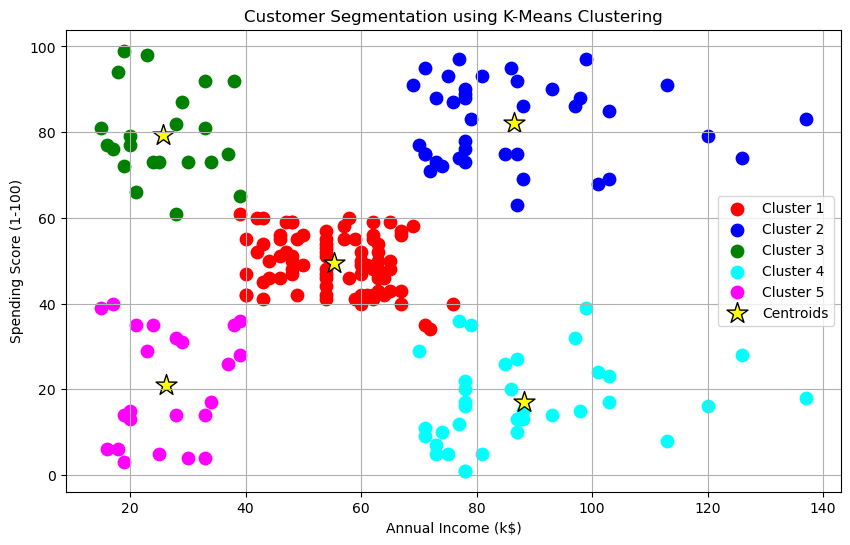

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    X[y_kmeans==0,0],
    X[y_kmeans==0,1],
    s=80,
    c='red',
    label='Cluster 1'
)

plt.scatter(
    X[y_kmeans==1,0],
    X[y_kmeans==1,1],
    s=80,
    c='blue',
    label='Cluster 2'
)

plt.scatter(
    X[y_kmeans==2,0],
    X[y_kmeans==2,1],
    s=80,
    c='green',
    label='Cluster 3'
)

plt.scatter(
    X[y_kmeans==3,0],
    X[y_kmeans==3,1],
    s=80,
    c='cyan',
    label='Cluster 4'
)

plt.scatter(
    X[y_kmeans==4,0],
    X[y_kmeans==4,1],
    s=80,
    c='magenta',
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    c='yellow',
    marker='*',
    edgecolors='black',
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.title("Customer Segmentation using K-Means Clustering")

plt.legend()

plt.grid(True)

plt.show()

## Step 7: Add Cluster Labels

The predicted cluster labels are added to the original dataset.

In [11]:
df["Cluster"] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Step 8: Save the Result

The clustered dataset is saved as a new CSV file.

In [12]:
df.to_csv("Customer_Segmentation_Result.csv", index=False)

print("Customer_Segmentation_Result.csv saved successfully.")

Customer_Segmentation_Result.csv saved successfully.


# Conclusion

In this project, we successfully applied the K-Means Clustering algorithm to segment customers based on their Annual Income and Spending Score.

The Elbow Method was used to determine the optimal number of clusters, and the final clustered data was visualized using a scatter plot. Customer segmentation can help businesses understand customer behavior and design better marketing strategies.